In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv("OnlineNewsPopularity.csv")
df

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,...,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,...,0.136364,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000,1900
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,...,0.136364,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,...,0.062500,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000,1100


In [3]:
rows = df.shape[0]
colum = df.shape[1]

print("Filas: ", rows)
print("Columnas: ", colum)

Filas:  39644
Columnas:  61


In [4]:
#Removes duplicates
df = df.drop_duplicates()
dp_rows = df.shape[0]
removed_rows = rows - dp_rows

print("Removed duplicated rows:", removed_rows)

Removed duplicated rows: 0


In [5]:
# Extract day of week
df['date'] = df['url'].str.extract(r'(\d{4}/\d{2}/\d{2})')

# Transform to date format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract year
df['year'] = df['date'].dt.year

# Extracts article title from url
df['title'] = df['url'].str.extract(r'\d{4}/\d{2}/\d{2}/(.+?)/?$')
df['title'] = df['title'].str.replace('-', ' ', regex=False).str.title()

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Get the list of data channel columns
channels = [col for col in df.columns if col.startswith('data_channel_is_')]

# Create a new column 'channel' that indicates the data channel for each article
def get_channel(row):
    for channel in channels:
        if row[channel] == 1:
            return channel.replace('data_channel_is_', '')
    return 'other' # Handle cases where no channel is marked

df['channel'] = df.apply(get_channel, axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   url                            39644 non-null  object        
 1   timedelta                      39644 non-null  float64       
 2   n_tokens_title                 39644 non-null  float64       
 3   n_tokens_content               39644 non-null  float64       
 4   n_unique_tokens                39644 non-null  float64       
 5   n_non_stop_words               39644 non-null  float64       
 6   n_non_stop_unique_tokens       39644 non-null  float64       
 7   num_hrefs                      39644 non-null  float64       
 8   num_self_hrefs                 39644 non-null  float64       
 9   num_imgs                       39644 non-null  float64       
 10  num_videos                     39644 non-null  float64       
 11  average_token_l

In [7]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timedelta,39644.0,354.530471,8.0,164.0,339.0,542.0,731.0,214.163767
n_tokens_title,39644.0,10.398749,2.0,9.0,10.0,12.0,23.0,2.114037
n_tokens_content,39644.0,546.514731,0.0,246.0,409.0,716.0,8474.0,471.107508
n_unique_tokens,39644.0,0.548216,0.0,0.47087,0.539226,0.608696,701.0,3.520708
n_non_stop_words,39644.0,0.996469,0.0,1.0,1.0,1.0,1042.0,5.231231
...,...,...,...,...,...,...,...,...
abs_title_subjectivity,39644.0,0.341843,0.0,0.166667,0.5,0.5,0.5,0.188791
abs_title_sentiment_polarity,39644.0,0.156064,0.0,0.0,0.0,0.25,1.0,0.226294
shares,39644.0,3395.380184,1.0,946.0,1400.0,2800.0,843300.0,11626.950749
date,39644,2014-01-18 03:20:21.551811328,2013-01-07 00:00:00,2013-07-15 00:00:00,2014-02-03 00:00:00,2014-07-27 00:00:00,2014-12-27 00:00:00,NaN


In [9]:
print("% of missing values\n")

# Missing Values
missing = (df.isna().sum() / df.isna().count()) * 100

# Filters columns with at least 1 missing value
missing_sorted = missing[missing > 0].sort_values(ascending=False)

# Verifica si hay columnas con faltantes
if not missing_sorted.empty:
    print('Columnas                  % faltantes')
    print(missing_sorted.round(2))
else:
    print("✅ No missing values on this data frame.")


% of missing values

✅ No missing values on this data frame.


In [10]:
unique_val = df.nunique()
unique_val.head(60).sort_values(ascending=False)

,0
url,39644
LDA_02,39525
LDA_04,39370
LDA_00,39337
kw_avg_avg,39300
LDA_01,39098
LDA_03,38963
global_sentiment_polarity,34695
global_subjectivity,34501
kw_avg_max,30834


In [11]:
#Articles by year

count_year = df['year'].value_counts().sort_index()

print("Articles by year:\n")
print(count_year)

Articles by year:

year
2013    18199
2014    21445
Name: count, dtype: int64


In [12]:
df['channel'].value_counts()

,count
channel,
world,8427
tech,7346
entertainment,7057
bus,6258
other,6134
socmed,2323
lifestyle,2099


In [13]:
# Extrae las columnas que comienzan con 'weekday_is'
days = [col for col in df.columns if col.startswith('weekday_is')]

# Selecciona esas columnas
df_days = df[days]

# Suma los valores por día
weekday_counts = df_days.sum()

# Muestra el resultado
print("🗓️ Articles by day of week:\n")
print(weekday_counts)

🗓️ Articles by day of week:

weekday_is_monday       6661.0
weekday_is_tuesday      7390.0
weekday_is_wednesday    7435.0
weekday_is_thursday     7267.0
weekday_is_friday       5701.0
weekday_is_saturday     2453.0
weekday_is_sunday       2737.0
dtype: float64


In [14]:
weekend_arts = df['is_weekend'].sum()
weekday_arts = df['url'].count() - weekend_arts

print("Weekday articles:", weekday_arts)
print("Weekend articles:", weekend_arts)

Weekday articles: 34454.0
Weekend articles: 5190.0


In [15]:
top_shares = df[['title', 'shares']].sort_values(by='shares', ascending=False).head(20)

print("Top 20 most shared articles:\n")
print(top_shares)

Top 20 most shared articles:

                                                   title  shares
9365                                     Low Cost Iphone  843300
5370                             Dove Ad Beauty Sketches  690400
23237                First 100 Gilt Soundcloud Stitchfix  663600
16268                         Kanye West Harvard Lecture  652900
3145                                   Wealth Inequality  617900
16009                                  Roomba 880 Review  441000
18788                          Australia Heatwave Photos  310800
4506                                Blackberry 1 Million  306100
16113                                   Ibm Watson Brief  298400
35256                        Ebola Cdc Active Monitoring  284700
14757                                  Childhood Mashups  233400
3043                                 Myspace Tom Twitter  227300
37590                                        Email Myths  211600
9853                      Sprint Unlimited Data For Life  21

In [16]:
# Count articles by channel, including the 'unknown' category
chanel_counts = df['channel'].value_counts()

print("Articles by chanel:\n")
print(chanel_counts)

Articles by chanel:

channel
world            8427
tech             7346
entertainment    7057
bus              6258
other            6134
socmed           2323
lifestyle        2099
Name: count, dtype: int64


In [17]:
# Get the list of data channel columns

# Select top 20 articles by shares, including the new 'channel' column
top_shares = df[['title', 'url', 'shares', 'channel']].sort_values(by='shares', ascending=False).head(20)

print("Top 20 most shared articles with channel information:\n")
display(top_shares)

Top 20 most shared articles with channel information:



,title,url,shares,channel
9365,Low Cost Iphone,http://mashable.com/2013/07/03/low-cost-iphone/,843300,other
5370,Dove Ad Beauty Sketches,http://mashable.com/2013/04/15/dove-ad-beauty-...,690400,bus
23237,First 100 Gilt Soundcloud Stitchfix,http://mashable.com/2014/04/09/first-100-gilt-...,663600,tech
16268,Kanye West Harvard Lecture,http://mashable.com/2013/11/18/kanye-west-harv...,652900,bus
3145,Wealth Inequality,http://mashable.com/2013/03/02/wealth-inequality/,617900,other
16009,Roomba 880 Review,http://mashable.com/2013/11/12/roomba-880-review/,441000,other
18788,Australia Heatwave Photos,http://mashable.com/2014/01/14/australia-heatw...,310800,bus
4506,Blackberry 1 Million,http://mashable.com/2013/03/28/blackberry-1-mi...,306100,bus
16113,Ibm Watson Brief,http://mashable.com/2013/11/14/ibm-watson-brief/,298400,bus
35256,Ebola Cdc Active Monitoring,http://mashable.com/2014/10/22/ebola-cdc-activ...,284700,world


In [18]:
# Calculate total shares by channel, including the 'other' category
shares_by_channel = df.groupby('channel')['shares'].sum().sort_values(ascending=False)

# Convert the Series to a DataFrame for better display
shares_by_channel_df = shares_by_channel.reset_index()
shares_by_channel_df.columns = ['channel', 'shares']

# Calculate percentage of total shares
shares_by_channel_df['percentage'] = (shares_by_channel_df['shares'] / shares_by_channel_df['shares'].sum()) * 100

print("Total shares and percentage by channel:\n")
display(shares_by_channel_df)

Total shares and percentage by channel:



,channel,shares,percentage
0,other,36467793,27.092158
1,tech,22568993,16.766650
2,entertainment,20962727,15.573345
3,world,19278735,14.322296
4,bus,19168370,14.240306
5,socmed,8431057,6.263487
6,lifestyle,7728777,5.741758


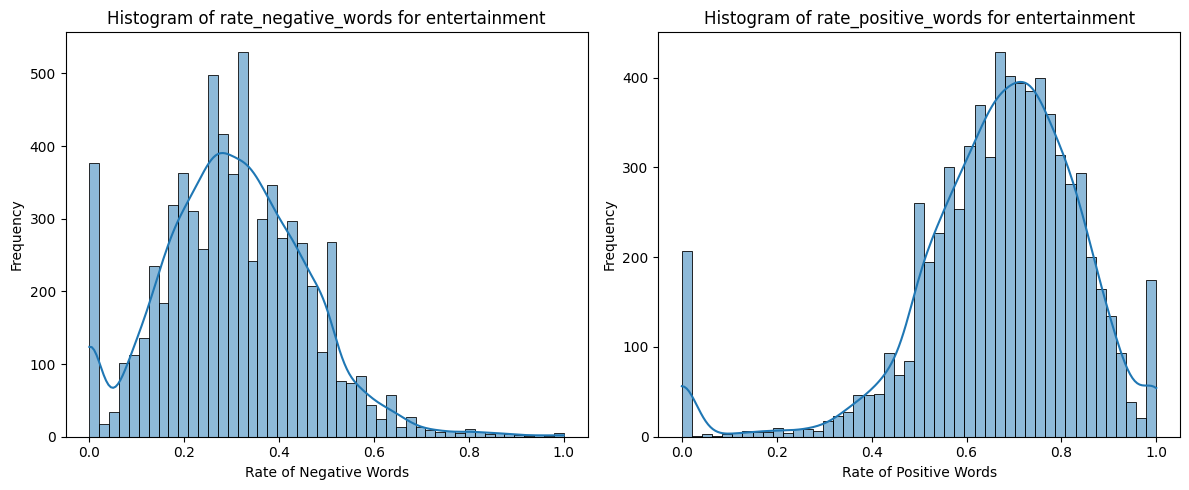

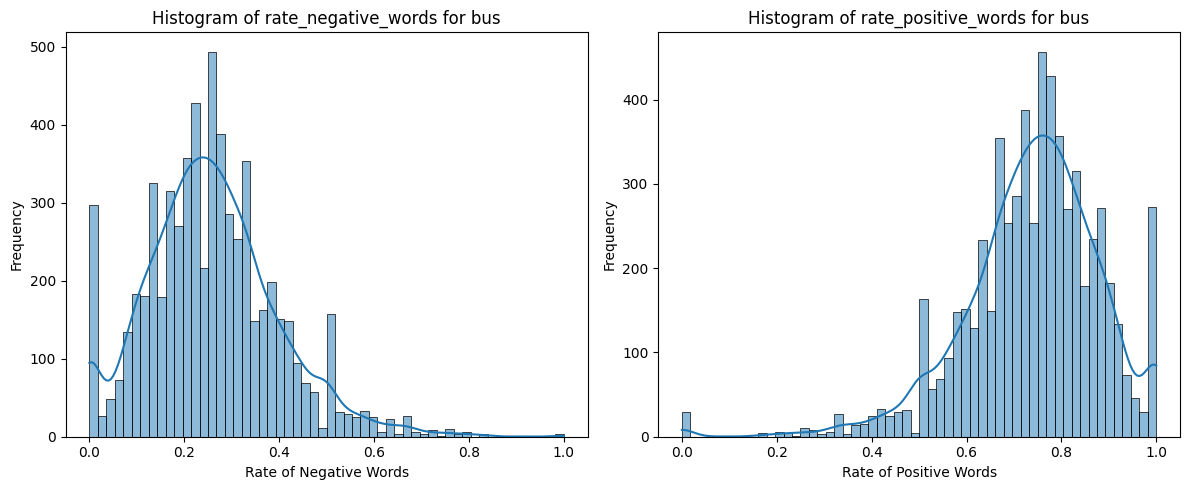

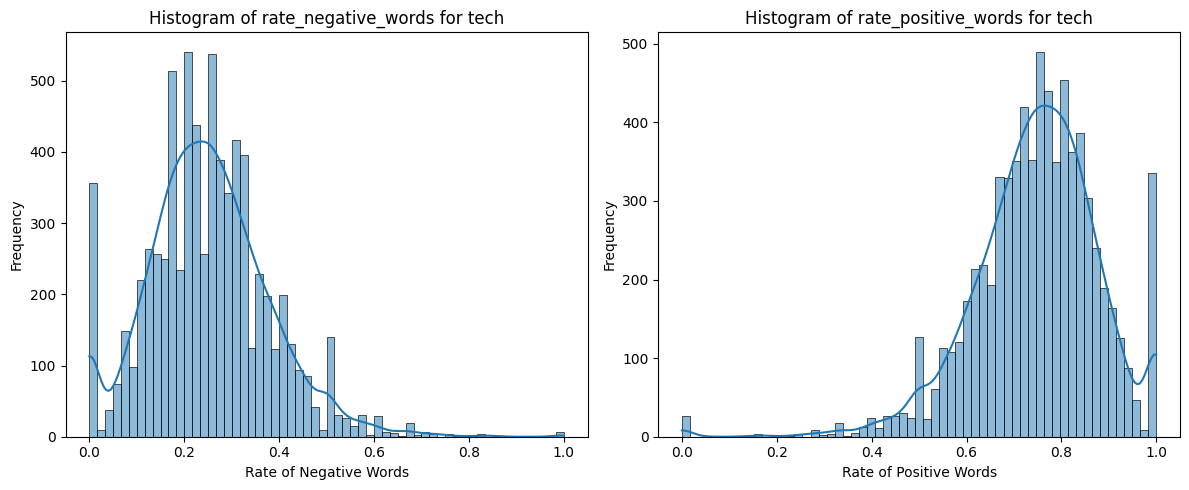

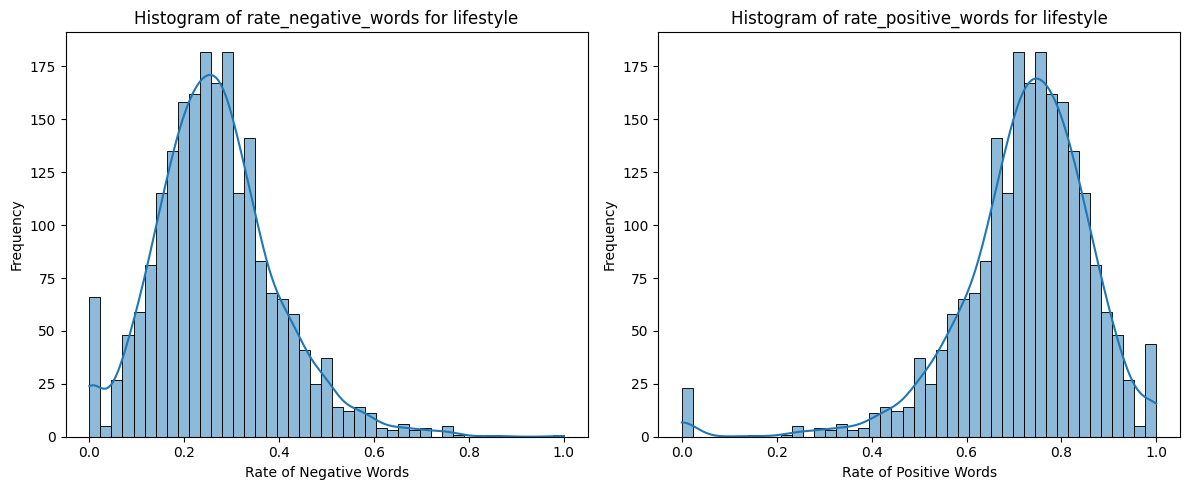

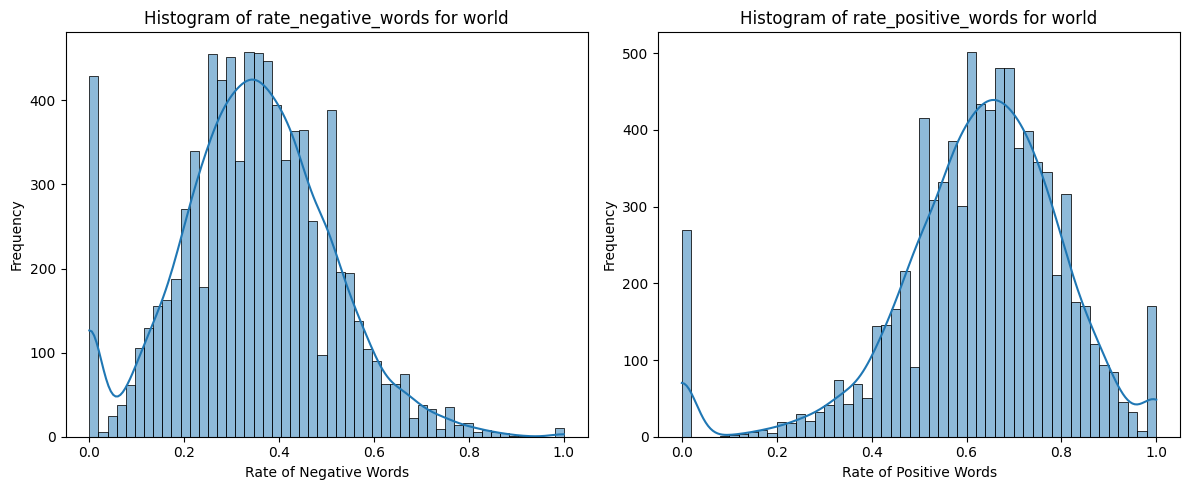

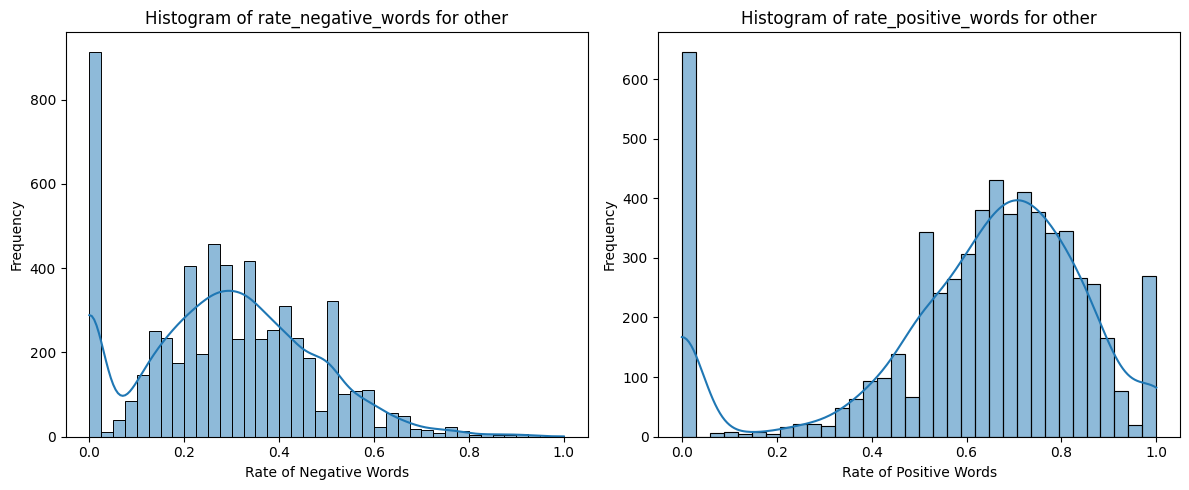

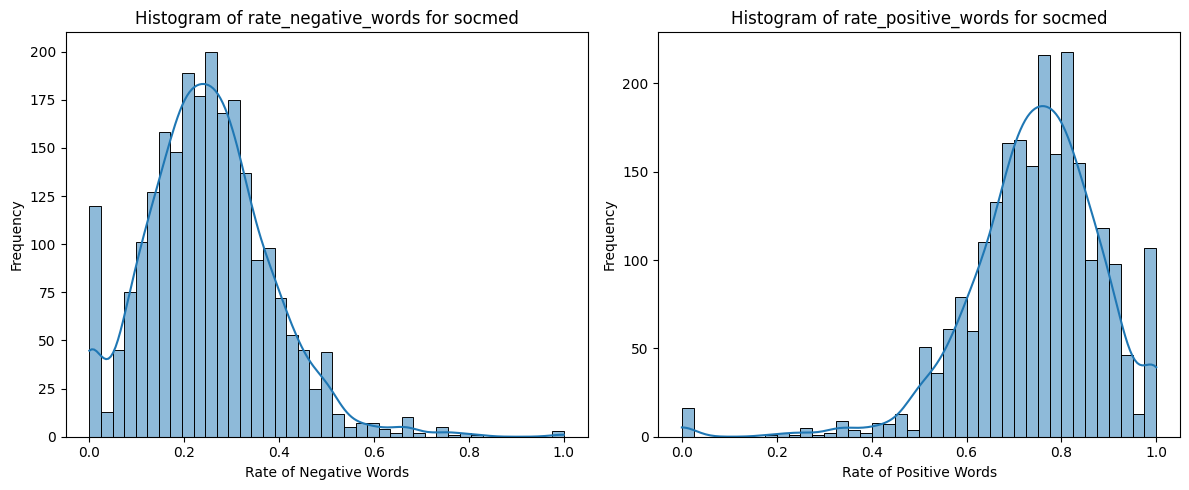

In [19]:
# Get the list of unique channels
channels = df['channel'].unique()

# Iterate through each channel and plot histograms
for channel in channels:
    # Filter data for the specific channel
    df_chanel = df[df['channel'] == channel]

    # Create histograms
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df_chanel['rate_negative_words'], kde=True)
    plt.title(f'Histogram of rate_negative_words for {channel}')
    plt.xlabel('Rate of Negative Words')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.histplot(df_chanel['rate_positive_words'], kde=True)
    plt.title(f'Histogram of rate_positive_words for {channel}')
    plt.xlabel('Rate of Positive Words')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [20]:
image_counts_df = df.groupby('channel')['num_imgs'].sum().sort_values(ascending=False)
video_counts_df = df.groupby('channel')['num_videos'].sum().sort_values(ascending=False)

print("Images by channel:\n")
display(image_counts_df)

print("\nVideos by channel:\n")
display(video_counts_df)

Images by channel:



,num_imgs
channel,
other,47467.0
entertainment,44584.0
tech,32576.0
world,23943.0
bus,11317.0
lifestyle,10295.0
socmed,9966.0



Videos by channel:



,num_videos
channel,
entertainment,17966.0
other,16092.0
world,4631.0
bus,3983.0
tech,3285.0
socmed,2596.0
lifestyle,997.0
